In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv("Unemployment in India.csv")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)
print(df.head())


FIRST FIVE ROWS
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [3]:
df.columns = df.columns.str.strip()

print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())


Dataset Shape:
(768, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None

Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Une

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [6]:
df.dropna(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)


Dataset Shape After Cleaning:
(740, 7)


In [7]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

print("\nAverage Unemployment Rate by Region:")
print(region_avg)


Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


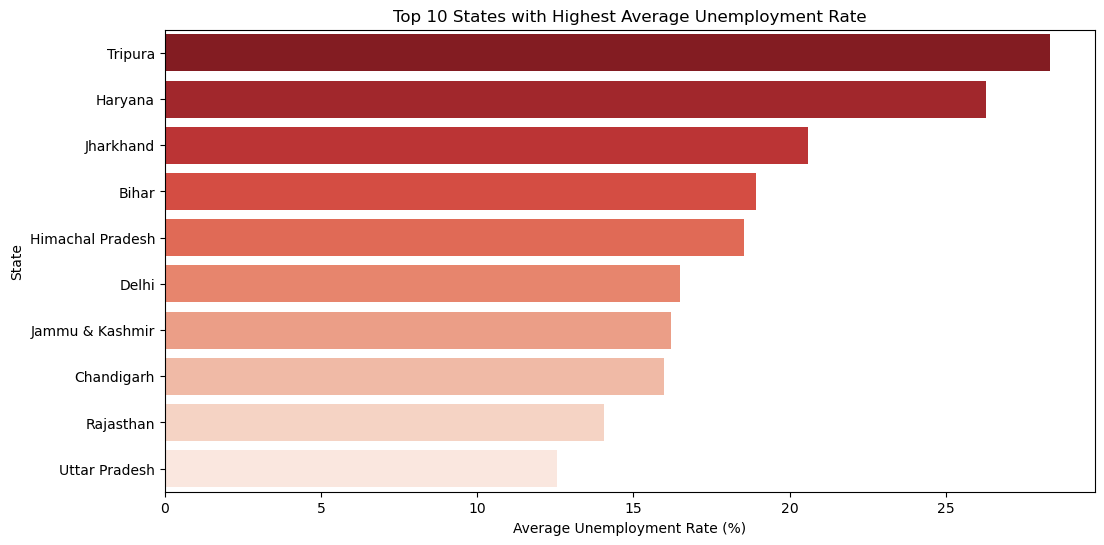

In [8]:
top10 = region_avg.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Reds_r"
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

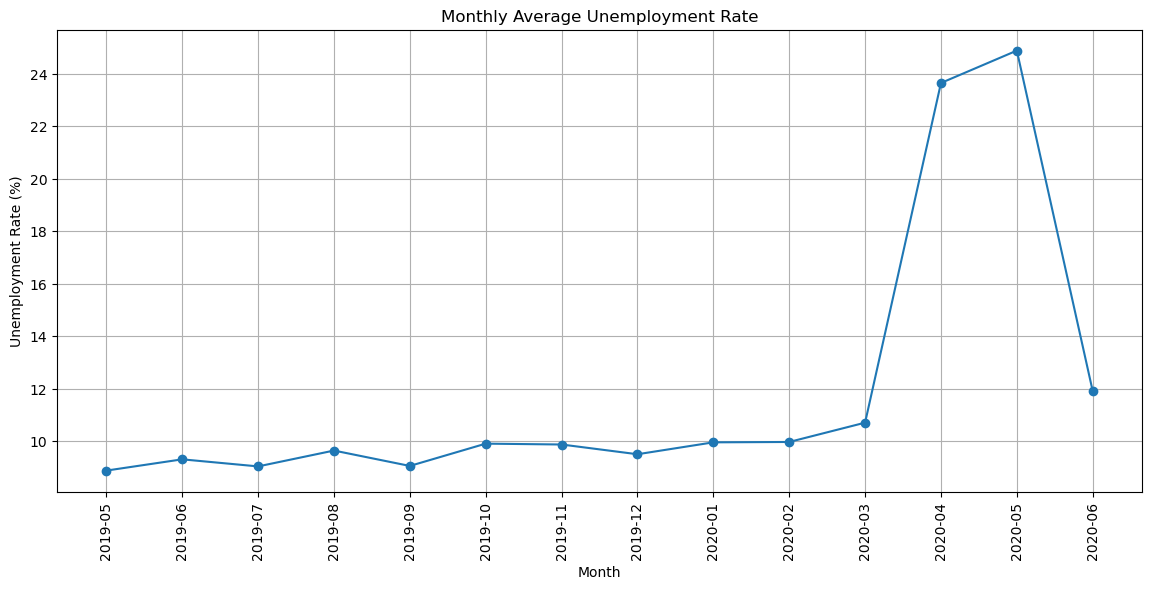

In [9]:
monthly = df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"].mean()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14,6))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.xticks(rotation=90)

plt.title("Monthly Average Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()


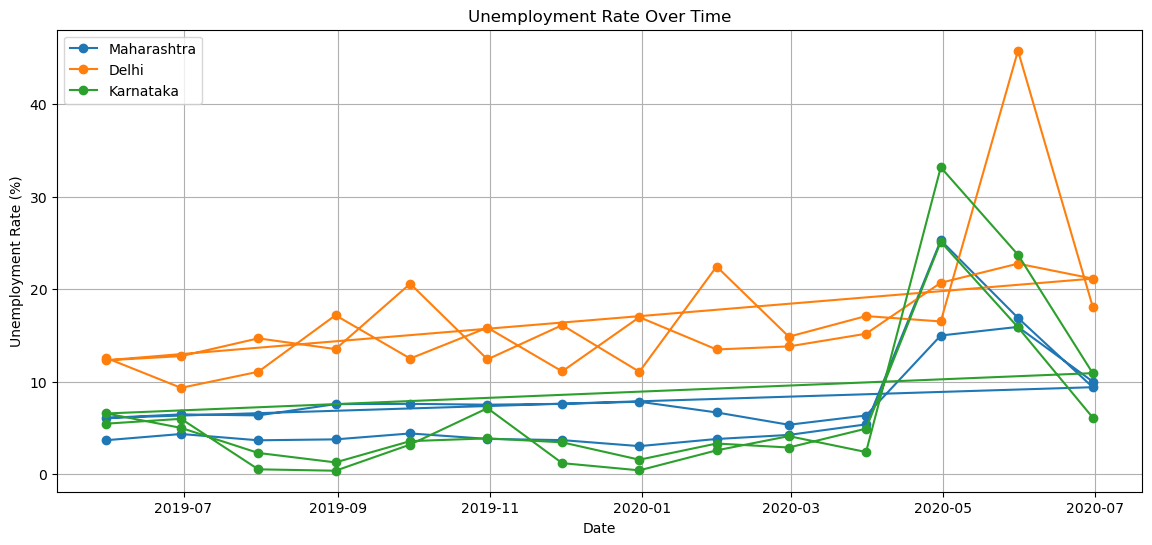

In [10]:
states = ["Maharashtra","Delhi","Karnataka"]

plt.figure(figsize=(14,6))

for state in states:

    state_data = df[df["Region"]==state]

    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker='o',
        label=state
    )

plt.legend()

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()


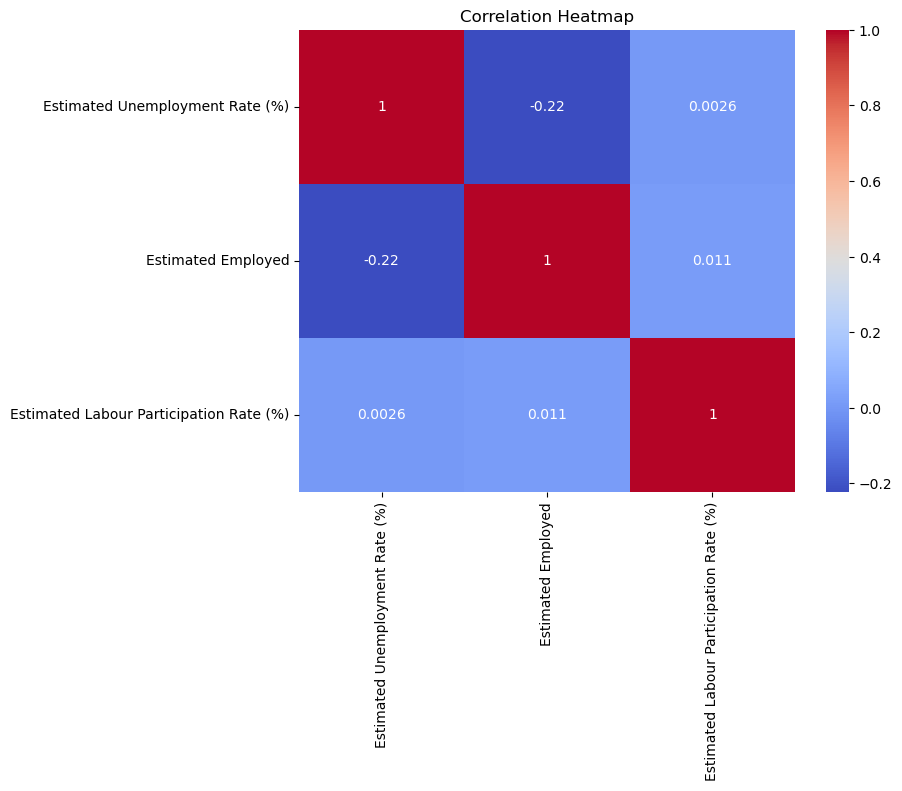

In [11]:
corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()



Pre vs Post COVID Comparison
       Period  Average Unemployment Rate
0   Pre-COVID                   9.509534
1  Post-COVID                  17.774363


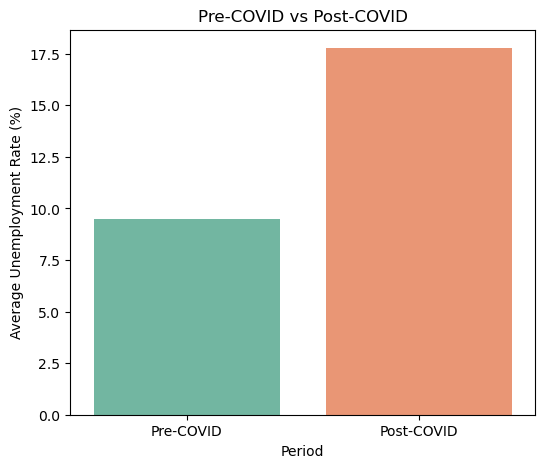

In [12]:
covid_date = pd.to_datetime("2020-03-25")

pre = df[df["Date"] < covid_date]

post = df[df["Date"] >= covid_date]

pre_avg = pre["Estimated Unemployment Rate (%)"].mean()

post_avg = post["Estimated Unemployment Rate (%)"].mean()

comparison = pd.DataFrame({

    "Period":[
        "Pre-COVID",
        "Post-COVID"
    ],

    "Average Unemployment Rate":[
        pre_avg,
        post_avg
    ]

})

print("\nPre vs Post COVID Comparison")
print(comparison)

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate",
    palette="Set2"
)

plt.title("Pre-COVID vs Post-COVID")

plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [13]:
print("\n")
print("="*60)
print("OBSERVATIONS")
print("="*60)

print("""
1. Dataset loaded successfully.

2. Missing values were checked and removed.

3. Region-wise unemployment rates were calculated.

4. Top 10 states with highest unemployment were visualized.

5. Monthly unemployment trend was plotted.

6. Time-series analysis was performed for Maharashtra,
   Delhi and Karnataka.

7. Correlation heatmap shows relationships among
   unemployment rate, employment and labour participation.

8. Pre-COVID and Post-COVID unemployment rates were compared.

9. Post-COVID unemployment rate is generally higher,
   showing the economic impact of the pandemic.

10. The analysis provides insights into regional and
    temporal unemployment patterns in India.
""")



OBSERVATIONS

1. Dataset loaded successfully.

2. Missing values were checked and removed.

3. Region-wise unemployment rates were calculated.

4. Top 10 states with highest unemployment were visualized.

5. Monthly unemployment trend was plotted.

6. Time-series analysis was performed for Maharashtra,
   Delhi and Karnataka.

7. Correlation heatmap shows relationships among
   unemployment rate, employment and labour participation.

8. Pre-COVID and Post-COVID unemployment rates were compared.

9. Post-COVID unemployment rate is generally higher,
   showing the economic impact of the pandemic.

10. The analysis provides insights into regional and
    temporal unemployment patterns in India.

